<a href="https://colab.research.google.com/github/naveed8606/sentiment-analysis-spacy/blob/main/Sentiment_Analysis_spacy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
!pip install spacy
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 21.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [35]:
import spacy

nlp = spacy.load("en_core_web_sm")

doc = nlp("Testing cells")

for token in doc:
    print(token.text, token.lemma_)

Testing testing
cells cell


In [36]:
import pandas as pd

data = {
    "text": [
        "I love this movie",
        "This was terrible",
        "Amazing experience",
        "Worst product ever",
        "I am very happy",
        "I hate this"
    ],
    "label": ["positive", "negative", "positive", "negative", "positive", "negative"]
}

df = pd.DataFrame(data)
df

,text,label
0,I love this movie,positive
1,This was terrible,negative
2,Amazing experience,positive
3,Worst product ever,negative
4,I am very happy,positive
5,I hate this,negative


In [37]:
def preprocess_text(text):
    doc = nlp(text)
    tokens = []

    for token in doc:
        if not token.is_stop and not token.is_punct:
            tokens.append(token.lemma_.lower())

    return " ".join(tokens)

df["cleaned"] = df["text"].apply(preprocess_text)

df

,text,label,cleaned
0,I love this movie,positive,love movie
1,This was terrible,negative,terrible
2,Amazing experience,positive,amazing experience
3,Worst product ever,negative,bad product
4,I am very happy,positive,happy
5,I hate this,negative,hate


In [38]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df["cleaned"])

y = df["label"]

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LogisticRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

    negative       0.50      1.00      0.67         1
    positive       0.00      0.00      0.00         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [40]:
def predict_sentiment(text):
    cleaned = preprocess_text(text)
    vectorized = vectorizer.transform([cleaned])
    prediction = model.predict(vectorized)
    return prediction[0]

print(predict_sentiment("I really enjoyed this!"))

negative


In [41]:
!jupyter nbconvert --to script Sentiment_Analysis_spacy.ipynb

[NbConvertApp] WARNING | pattern 'Sentiment_Analysis_spacy.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=True]


In [58]:
import pandas as pd

url = "https://raw.githubusercontent.com/naveed8606/sentiment-analysis-spacy/main/data/sample.csv"
df = pd.read_csv(url)

print(len(df))
df.head()

103


,text,label
0,I absolutely loved this movie,positive
1,This product is amazing,positive
2,I am very happy with the service,positive
3,The experience was fantastic,positive
4,Really enjoyed using this app,positive


In [59]:
len(df)

103

In [60]:
df["cleaned"] = df["text"].apply(preprocess_text)

In [61]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(ngram_range=(1,2))
X = vectorizer.fit_transform(df["cleaned"])
y = df["label"]

In [62]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = LogisticRegression(max_iter=200, class_weight="balanced")
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=200)

In [63]:
from sklearn.metrics import classification_report

predictions = model.predict(X_test)
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

    negative       0.64      0.70      0.67        10
    positive       0.70      0.64      0.67        11

    accuracy                           0.67        21
   macro avg       0.67      0.67      0.67        21
weighted avg       0.67      0.67      0.67        21



In [64]:
print(predict_sentiment("This product is amazing"))
print(predict_sentiment("Worst experience ever"))

positive
negative


In [65]:
print(df["label"].value_counts())

label
positive    53
negative    50
Name: count, dtype: int64


In [66]:
feature_names = vectorizer.get_feature_names_out()
coefficients = model.coef_[0]

word_index = list(feature_names).index("amazing")
print("Weight of 'amazing':", coefficients[word_index])

Weight of 'amazing': 0.7824556172598085


In [67]:
import pandas as pd

url = "https://raw.githubusercontent.com/laxmimerit/All-CSV-ML-Data-Files-Download/master/IMDB-Dataset.csv"
df = pd.read_csv(url)

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [68]:
print(len(df))
print(df["sentiment"].value_counts())

50000
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [69]:
df.rename(columns={"review": "text", "sentiment": "label"}, inplace=True)

In [70]:
df = df.sample(5000, random_state=42)

In [71]:
len(df)

5000

In [74]:
df["cleaned"] = df["text"].apply(preprocess_text)

In [75]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(ngram_range=(1,2))
X = vectorizer.fit_transform(df["cleaned"])
y = df["label"]

In [76]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

LogisticRegression(max_iter=200)

In [77]:
from sklearn.metrics import classification_report, accuracy_score

predictions = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, predictions))
print(classification_report(y_test, predictions))

Accuracy: 0.844
              precision    recall  f1-score   support

    negative       0.88      0.79      0.83       496
    positive       0.81      0.89      0.85       504

    accuracy                           0.84      1000
   macro avg       0.85      0.84      0.84      1000
weighted avg       0.85      0.84      0.84      1000



In [78]:
print(predict_sentiment("This movie was amazing"))
print(predict_sentiment("Worst movie ever"))

positive
negative


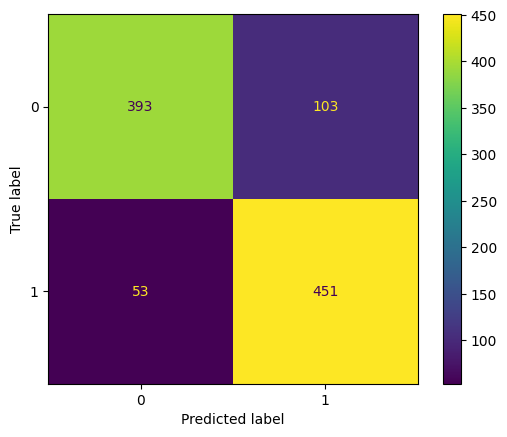

In [79]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()
plt.show()

In [80]:
print(predict_sentiment("I loved this movie so much"))
print(predict_sentiment("This was a complete waste of time"))
print(predict_sentiment("It was okay, not great"))

positive
negative
positive
